# Evaluación del modelo  

En este notebook se realiza la auditoría técnica de los modelos entrenados previamente para la predicción de deserción de clientes (Churn). Una vez obtenidos los mejores estimadores mediante GridSearchCV, el objetivo principal es determinar no solo qué modelo tiene el mejor rendimiento estadístico, sino también entender el "porqué" de sus predicciones y su capacidad de generalización ante datos no vistos.  

Esta etapa es crítica para asegurar que el modelo sea confiable antes de ser integrado en el ecosistema de MLOps y desplegado mediante la API.

## Objetivos a Desarrollar  

### **Evaluación de Métricas de Clasificación:**  

Carga de los artefactos serializados (.pkl y .parquet) para calcular y comparar el rendimiento final en el conjunto de prueba. Se analizarán indicadores clave como:

* Precision & Recall: Para entender el costo de los falsos positivos frente a los clientes perdidos no detectados.

* F1-Score: Como medida de equilibrio entre las métricas anteriores.

* ROC-AUC: Para evaluar la capacidad de separación de clases de cada algoritmo  

### Análisis de Errores (Matriz de Confusión y Curvas ROC)  

Visualización del comportamiento de los modelos para identificar sesgos o debilidades específicas en la clasificación de la clase minoritaria (clientes que abandonan el servicio).  

### Interpretabilidad Global (Feature Importance)  

Extracción y visualización de la importancia de las características (feature_importances_). El propósito es identificar las 10 variables que más influyen en la decisión de los modelos, proporcionando así información valiosa para la toma de decisiones de negocio.    

## Importaciones y carga de artefactos  

In [2]:
import joblib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

In [3]:
# Celda 2 — Carga de artefactos
ruta_base_data = "../data"

X_test = pd.read_parquet(f"{ruta_base_data}/X_test.parquet")
y_test = pd.read_parquet(f"{ruta_base_data}/y_test.parquet").squeeze()

models = {
    "Random Forest": joblib.load(f"{ruta_base_data}/models/rf_best.pkl"),
    "XGBoost":       joblib.load(f"{ruta_base_data}/models/xgb_best.pkl"),
    "CatBoost":      joblib.load(f"{ruta_base_data}/models/cb_best.pkl"),
    "LightGBM":      joblib.load(f"{ruta_base_data}/models/lgbm_best.pkl"),
}

print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")
print(f"Modelos cargados: {list(models.keys())}")

X_test: (1409, 19) | y_test: (1409,)
Modelos cargados: ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']


## Cálculo de métricas  

In [4]:
# Celda 3 — Cálculo de métricas
records = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    records.append({
        "Modelo":    name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
        "_y_pred":   y_pred,
        "_y_prob":   y_prob,
    })

metrics_df = (
    pd.DataFrame(records)
      .drop(columns=["_y_pred", "_y_prob"])
      .set_index("Modelo")
      .sort_values("ROC-AUC", ascending=False)
      .round(4)
)

metrics_df.style.background_gradient(cmap="YlGn")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
CatBoost,0.748800,0.517400,0.794100,0.626600,0.847800
XGBoost,0.743100,0.510400,0.786100,0.618900,0.844700
Random Forest,0.752300,0.521800,0.799500,0.631500,0.843900
LightGBM,0.765800,0.543500,0.735300,0.625000,0.828800


Esta tabla presenta un cuadro comparativo del rendimiento de los cuatro modelos evaluados (CatBoost, XGBoost, Random Forest y LightGBM) utilizando métricas clave de clasificación binaria. A través de un mapa de calor, se observa que LightGBM destaca en Accuracy (0.765) y Precision (0.543), lo que lo hace ideal si el objetivo es minimizar las falsas alarmas al predecir el Churn. Sin embargo, en un contexto de retención de clientes, el Random Forest muestra una ventaja competitiva crítica al alcanzar el Recall más alto (0.799), logrando identificar a casi el 80% de los clientes que realmente abandonaron el servicio.  

Por otro lado, la métrica ROC-AUC posiciona a CatBoost como el modelo más robusto (0.847), demostrando una capacidad superior para distinguir entre ambas clases independientemente del umbral de decisión establecido. En conjunto, los resultados sugieren un compromiso entre la precisión de las alertas y la capacidad de detección masiva. Mientras que Random Forest ofrece el mejor equilibrio general (F1-Score de 0.631).  

## Matriz de confusión por modelo  

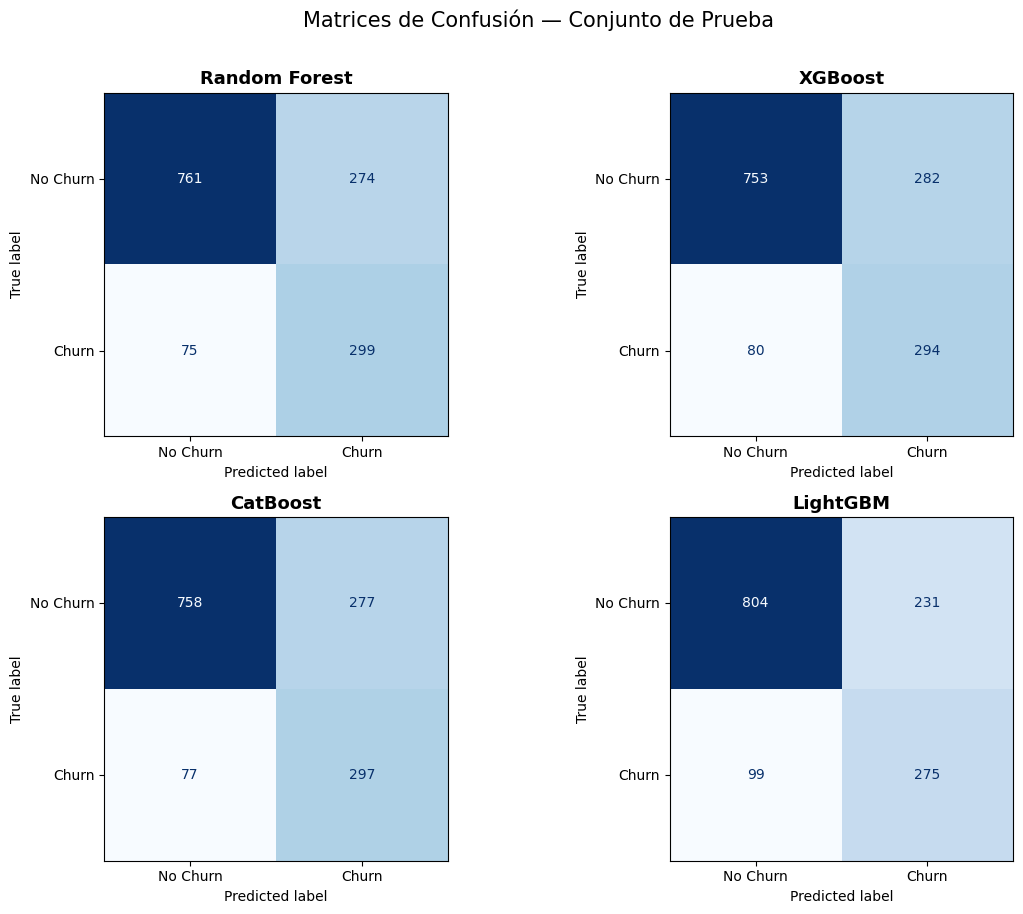

In [5]:
# Celda 4 — Matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, rec in zip(axes.flatten(), records):
    cm = confusion_matrix(y_test, rec["_y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])\
        .plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(rec["Modelo"], fontsize=13, fontweight="bold")

fig.suptitle("Matrices de Confusión — Conjunto de Prueba", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f"{ruta_base_data}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

En nuestro contexto de las telecomunicaciones, donde la detección temprana de la pérdida de clientes es crítica para la rentabilidad, el análisis de las Matrices de Confusión revela que Random Forest y CatBoost son los algoritmos más efectivos para capturar el riesgo de abandono. Random Forest lidera en la detección de casos reales de churn con 299 aciertos y la menor cantidad de falsos negativos (75), lo que minimiza las oportunidades perdidas de intervención. Esto permite identificar con mayor precisión el perfil de clientes con alta probabilidad de salida para ejecutar estrategias de retención oportunas como ofertas en los planes o mejores tasas de interés por mora.

Por otro lado, LightGBM demuestra ser el modelo más eficiente en el uso de recursos de campaña, al generar la menor cantidad de falsas alarmas (231 falsos positivos). Aunque este enfoque es más conservador y deja pasar más casos de fuga (99), optimiza los costos operativos en una arquitectura de MLOps al dirigir las acciones de fidelización solo a quienes tienen una certeza estadística mayor de irse. Esta comparativa permite diseñar un flujo de trabajo donde la elección del modelo final dependa de si la empresa prioriza la cobertura total del riesgo o la eficiencia del gasto publicitario.

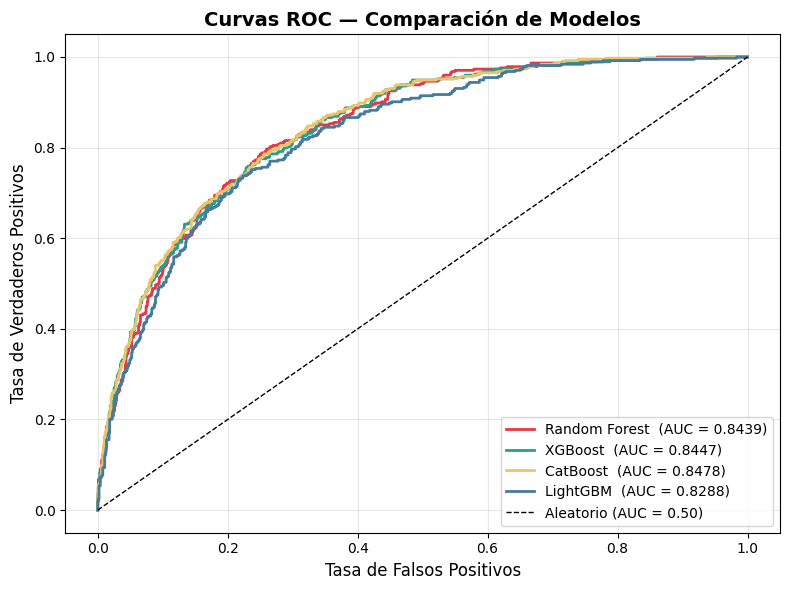

In [6]:
# Celda 5 — Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#E63946", "#2A9D8F", "#E9C46A", "#457B9D"]

for rec, color in zip(records, colors):
    fpr, tpr, _ = roc_curve(y_test, rec["_y_prob"])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{rec['Modelo']}  (AUC = {rec['ROC-AUC']:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio (AUC = 0.50)")
ax.set_xlabel("Tasa de Falsos Positivos", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos", fontsize=12)
ax.set_title("Curvas ROC — Comparación de Modelos", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{ruta_base_data}/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

El análisis de las Curvas ROC confirma que los modelos poseen una alta capacidad de discriminación, con valores de AUC que superan el 0.82 en todos los casos. CatBoost se posiciona como el clasificador más robusto con un AUC de 0.8478, lo que indica una probabilidad cercana al 85% de clasificar correctamente el riesgo de un desertor frente a un cliente fiel. Esta métrica es fundamental en una arquitectura de MLOps, ya que asegura que el modelo es capaz de ordenar eficazmente a los clientes según su nivel de criticidad, permitiendo establecer umbrales de decisión flexibles según la estrategia comercial de la empresa.  

A pesar de que las curvas de XGBoost y Random Forest muestran un rendimiento casi idéntico al de CatBoost, la ligera superioridad de este último en el área bajo la curva lo convierte en el candidato ideal para liderar el proceso de intervención oportuna. En el entorno de producción, contar con un AUC sólido garantiza que las predicciones de churn no son aleatorias, sino que están respaldadas por una separación estadística clara entre los perfiles de abandono y permanencia, facilitando la toma de decisiones informadas para reducir las tasas de pérdida de clientes en el sector.  